# Ticket Classification — Preprocessing
**Project:** naive-bayes-tickets  
**Stage:** EDA/Cleaning → Preprocessing → Model Training

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR = os.path.abspath("..")
DATA_DIR      = os.path.join(BASE_DIR, 'data', 'processed')
FIGURES_DIR = os.path.join(BASE_DIR,'reports', 'figures')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')

INPUT_PATH  = os.path.join(DATA_DIR, 'tickets_cleaned.csv')
OUTPUT_PATH = os.path.join(DATA_DIR, 'tickets_nb_ready.csv')

os.makedirs(DATA_DIR,      exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20

## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df[['ticket_description', 'ticket_type']].dropna().reset_index(drop=True)

print(df.shape)
print(df['ticket_type'].value_counts())

(8469, 2)
ticket_type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


## 2. Text Preprocessing

Pipeline per ticket description:
1. Lowercase
2. Remove URLs, emails, alphanumeric IDs
3. Remove punctuation
4. Tokenize
5. Remove stopwords — negations kept (`not`, `never`, `cannot`, etc.) since they carry meaning in support context
6. Lemmatize

In [3]:
lemmatizer = WordNetLemmatizer()

NEGATIONS = {
    'no', 'not', 'nor', 'neither', 'never', 'none', 'without',
    'cannot', "can't", "won't", "don't", "didn't", "isn't",
    "aren't", "wasn't", "weren't", "hasn't", "haven't", "hadn't"
}

STOP_WORDS = set(stopwords.words('english')) - NEGATIONS


def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'#?\b[a-z]*\d+[a-z0-9]*\b', ' ', text)
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r"(?<![a-z])'", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

In [4]:
df['clean_description'] = df['ticket_description'].apply(preprocess_text)

empty_mask = df['clean_description'].str.strip() == ''
print(f'Empty after cleaning: {empty_mask.sum()}')
df = df[~empty_mask].reset_index(drop=True)

df.head(3)

Empty after cleaning: 0


,ticket_description,ticket_type,clean_description
0,I'm having an issue with the GoPro Hero. Pleas...,Technical issue,issue gopro hero please assist billing zip cod...
1,I'm having an issue with the LG Smart TV. Plea...,Technical issue,issue smart please assist need change existing...
2,I'm facing a problem with my Dell XPS. The Del...,Technical issue,facing problem dell xps dell xps not turning w...


## 3. Feature Engineering

Numeric features that supplement TF-IDF. Naive Bayes on TF-IDF alone treats 
every ticket as a bag of words — these features give the model structural and 
behavioral signals it cannot see from token frequencies.

In [5]:
# Raw text features
df['char_count']        = df['ticket_description'].str.len()
df['word_count_raw']    = df['ticket_description'].str.split().str.len()
df['avg_word_len']      = df['char_count'] / (df['word_count_raw'] + 1e-9)
df['sentence_count']    = df['ticket_description'].str.count(r'[.!?]+')
df['exclamation_count'] = df['ticket_description'].str.count(r'!')
df['question_count']    = df['ticket_description'].str.count(r'\?')
df['upper_ratio']       = df['ticket_description'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1e-9)
)

# Clean text features
df['word_count_clean'] = df['clean_description'].str.split().str.len()
df['unique_word_ratio'] = df['clean_description'].apply(
    lambda x: len(set(x.split())) / (len(x.split()) + 1e-9)
)

# Keyword flags — one per ticket class
KEYWORD_GROUPS = {
    'flag_refund'       : r'\b(refund|reimburse|money back|return|chargeback)\b',
    'flag_technical'    : r'\b(error|bug|crash|not work|broken|fail|issue|glitch|freeze|hang)\b',
    'flag_cancellation' : r'\b(cancel|cancellation|terminate|end subscription|unsubscribe)\b',
    'flag_product'      : r'\b(how to|feature|compatible|specification|version|upgrade|install)\b',
    'flag_billing'      : r'\b(bill|invoice|payment|charge|overcharg|subscription|price|cost)\b',
}

for col, pattern in KEYWORD_GROUPS.items():
    df[col] = df['ticket_description'].str.lower().str.contains(pattern, regex=True).astype(int)

FEAT_COLS = [
    'char_count', 'word_count_raw', 'avg_word_len', 'sentence_count',
    'exclamation_count', 'question_count', 'upper_ratio',
    'word_count_clean', 'unique_word_ratio'
] + list(KEYWORD_GROUPS.keys())

df[FEAT_COLS].describe().round(3)

,char_count,word_count_raw,avg_word_len,sentence_count,exclamation_count,question_count,upper_ratio,word_count_clean,unique_word_ratio,flag_refund,flag_technical,flag_cancellation,flag_product,flag_billing
count,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000,8469.000
mean,281.972,48.539,5.854,4.869,0.073,0.513,0.044,25.410,0.865,0.025,0.940,0.003,0.109,0.071
std,43.995,8.620,0.488,1.305,0.305,0.652,0.016,4.636,0.078,0.156,0.237,0.053,0.312,0.256
min,135.000,21.000,3.541,3.000,0.000,0.000,0.017,11.000,0.348,0.000,0.000,0.000,0.000,0.000
25%,263.000,45.000,5.545,4.000,0.000,0.000,0.034,23.000,0.821,0.000,1.000,0.000,0.000,0.000
50%,290.000,51.000,5.797,5.000,0.000,0.000,0.041,26.000,0.870,0.000,1.000,0.000,0.000,0.000
75%,310.000,55.000,6.089,6.000,0.000,1.000,0.050,29.000,0.923,0.000,1.000,0.000,0.000,0.000
max,402.000,67.000,9.680,15.000,6.000,6.000,0.275,46.000,1.000,1.000,1.000,1.000,1.000,1.000


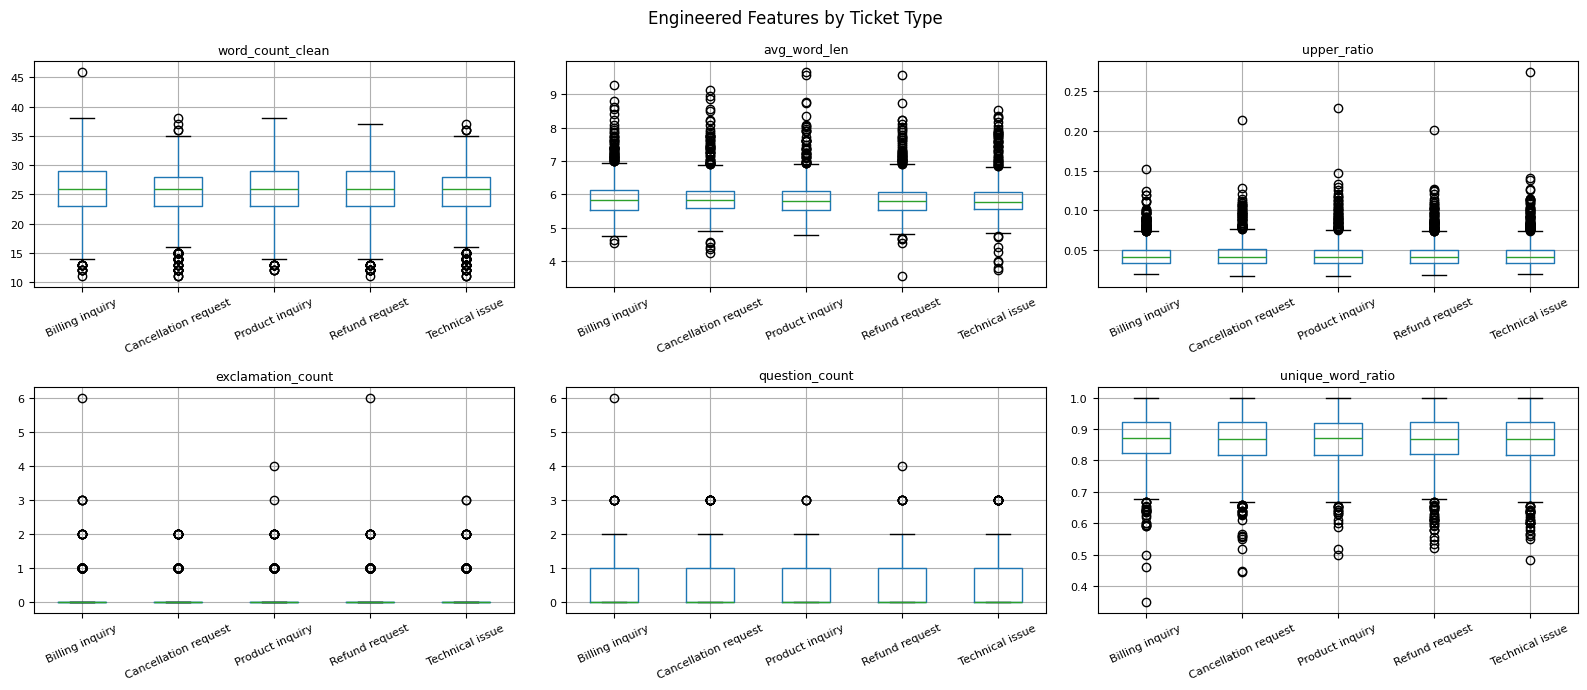

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
plot_features = [
    'word_count_clean', 'avg_word_len', 'upper_ratio',
    'exclamation_count', 'question_count', 'unique_word_ratio'
]

for ax, feat in zip(axes.flatten(), plot_features):
    df.boxplot(column=feat, by='ticket_type', ax=ax, rot=25, fontsize=8)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Engineered Features by Ticket Type')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_boxplots.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Label Encoding

In [7]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['ticket_type'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

{'Billing inquiry': np.int64(0), 'Cancellation request': np.int64(1), 'Product inquiry': np.int64(2), 'Refund request': np.int64(3), 'Technical issue': np.int64(4)}


## 5. Train / Test Split

Split before TF-IDF fit to prevent data leakage.  
`stratify=y` preserves class distribution across both sets.

In [8]:
X_text = df['clean_description']
y      = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

train_idx = X_train_text.index
test_idx  = X_test_text.index

print(f'Train: {len(y_train)}  |  Test: {len(y_test)}')
print(pd.Series(y_train).map({v: k for k, v in label_mapping.items()}).value_counts())

Train: 6775  |  Test: 1694
label
Refund request          1401
Technical issue         1398
Cancellation request    1356
Product inquiry         1313
Billing inquiry         1307
Name: count, dtype: int64


## 6. TF-IDF Vectorization

| Parameter | Value | Reason |
|---|---|---|
| `ngram_range` | (1, 2) | Unigrams + bigrams capture class-defining phrases like *refund request*, *billing inquiry* |
| `max_features` | 20000 | Wide vocabulary benefits Multinomial NB; sparse high-dim works well for it |
| `min_df` | 2 | Remove hapax legomena that are pure noise |
| `max_df` | 0.85 | Remove near-universal terms that survive stopword removal |
| `sublinear_tf` | True | Log-scale TF prevents high-frequency terms from dominating |
| `norm` | l2 | Standard cosine normalization across documents |

Fit only on train. Transform both.

In [9]:
tfidf = TfidfVectorizer(
    ngram_range  = (1, 2),
    max_features = 20_000,
    min_df       = 2,
    max_df       = 0.85,
    sublinear_tf = True,
    strip_accents= 'unicode',
    norm         = 'l2',
    analyzer     = 'word',
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f'Vocabulary : {len(tfidf.vocabulary_):,}')
print(f'Train      : {X_train_tfidf.shape}')
print(f'Test       : {X_test_tfidf.shape}')
print(f'Density    : {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.5f}')

with open(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

Vocabulary : 10,100
Train      : (6775, 10100)
Test       : (1694, 10100)
Density    : 0.00391


In [10]:
feature_names = tfidf.get_feature_names_out()
inv_map = {v: k for k, v in label_mapping.items()}

for label_id in sorted(inv_map):
    mask       = (y_train == label_id).values
    mean_score = X_train_tfidf[mask].toarray().mean(axis=0)
    top_terms  = feature_names[mean_score.argsort()[-12:][::-1]]
    print(f'{inv_map[label_id]}')
    print(' ', ', '.join(top_terms), '\n')

Billing inquiry
  please, assist, please assist, ve, product, problem, not, update, work, data, device, time 

Cancellation request
  please, assist, please assist, ve, product, problem, not, update, device, step, work, time 

Product inquiry
  please, assist, please assist, ve, product, problem, not, update, data, software, device, time 

Refund request
  please, assist, please assist, ve, product, problem, not, update, device, error, data, software 

Technical issue
  please, assist, please assist, ve, product, problem, not, device, update, step, error, software 



## 7. Save Processed Dataset

Output columns:
- `ticket_description` — original text (for inspection)
- `clean_description` — preprocessed text (model input)
- `ticket_type` — original label
- `label` — encoded label
- `split` — train / test marker
- all engineered feature columns

In [11]:
df['split'] = 'train'
df.loc[test_idx, 'split'] = 'test'

output_cols = [
    'ticket_description', 'clean_description',
    'ticket_type', 'label', 'split'
] + FEAT_COLS

df[['clean_description', 'label']].to_csv(OUTPUT_PATH, index=False)

print(f'Saved  : {OUTPUT_PATH}')
print(f'Shape  : {df[output_cols].shape}')
print(f'Train  : {df["split"].eq("train").sum()}')
print(f'Test   : {df["split"].eq("test").sum()}')
print(f'Saved PKLS: {os.listdir(MODEL_DIR)}')

Saved  : c:\Users\Victus\Music\Datascience\Projects\support_tickets_classifier\naive-bayes-tickets\data\processed\tickets_nb_ready.csv
Shape  : (8469, 19)
Train  : 6775
Test   : 1694
Saved PKLS: ['label_encoder.pkl', 'naive_bayes_model.pkl', 'scaler.pkl', 'tfidf_vectorizer.pkl']
